# 4. Redes Neuronales y Deep Learning para Series de Tiempo Financieras

Los modelos provinientes de la regresión lineal, como modelos de clasificación clásicos suponen relaciones relativamente simples entre las variables. Las redes neuronales, en cambio, pueden aprender **relaciones no lineales complejas** directamente de los datos, sin que tengamos que especificar a mano la forma funcional. Esto las hace atractivas para series de tiempo financieras, donde la relación entre el pasado y el futuro de un precio rara vez es lineal.

En este cuaderno recorremos el proceso completo de un proyecto de *forecasting* con *deep learning*:

1. Descarga de datos reales de mercado con `yfinance` (Yahoo Finance).
2. Preprocesamiento y construcción de ventanas deslizantes para aprendizaje supervisado.
3. Entrenamiento de dos arquitecturas: un **Perceptrón Multicapa (MLP)** sencillo y una red recurrente **LSTM (Deep Learning)**.
4. Diagnóstico del desempeño frente a una línea base ingenua (*random walk*).
5. Predicción *one-step-ahead* (un paso adelante) para el siguiente día hábil.

> **Advertencia:** este cuaderno tiene fines exclusivamente educativos. Ningún resultado aquí constituye una recomendación de inversión.

In [1]:
# Importación de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

print(f"TensorFlow: {tf.__version__}  |  Keras: {keras.__version__}")

TensorFlow: 2.21.0  |  Keras: 3.15.1


## 1. ¿Por qué redes neuronales para series de tiempo?

| | Modelos clásicos (ARIMA, regresión) | Redes neuronales (MLP, LSTM) |
|---|---|---|
| Relación pasado-futuro | Lineal (o requiere transformación manual) | No lineal, aprendida automáticamente |
| *Feature engineering* | Manual (rezagos, medias móviles, diferenciación) | Puede aprenderse a partir de ventanas crudas |
| Datos necesarios | Funciona con series cortas | Requiere volúmenes de datos considerables |
| Interpretabilidad | Alta (coeficientes con significado) | Baja (caja negra) |
| Riesgo de sobreajuste | Menor | Mayor si el modelo es muy grande frente a los datos |

En este cuaderno comparamos dos arquitecturas con roles distintos:

- **MLP (Perceptrón Multicapa):** recibe la ventana de precios pasados como un vector plano. No tiene ninguna noción incorporada de "orden temporal": para el MLP, la ventana es simplemente un conjunto de `N` números.
- **LSTM (*Long Short-Term Memory*):** es una red recurrente diseñada específicamente para secuencias. Procesa la ventana paso a paso, manteniendo un estado interno ("memoria") que le permite ponderar de forma distinta la información reciente y la más antigua.

La comparación entre ambas nos permite responder una pregunta central en *deep learning* para series de tiempo: **¿aporta algo la estructura recurrente frente a una red densa "ingenua"?**

## 2. Descarga de datos: Yahoo Finance con `yfinance`

`yfinance` es una librería de Python que consulta la API pública de Yahoo Finance y devuelve precios históricos en un `DataFrame` de `pandas`. Trabajaremos con el precio de cierre ajustado (`auto_adjust=True`, que ya incorpora ajustes por splits y dividendos) de una acción individual.

In [2]:
TICKER = "AAPL"
FECHA_INICIO = "2015-01-01"

datos = yf.download(TICKER, start=FECHA_INICIO, auto_adjust=True, progress=False)

# yfinance devuelve las columnas con un MultiIndex (Precio, Ticker), incluso
# al descargar un solo activo. Lo aplanamos para trabajar con nombres simples.
datos.columns = datos.columns.get_level_values(0)

print(f"Periodo descargado: {datos.index.min().date()} -> {datos.index.max().date()}")
print(f"Número de observaciones: {len(datos)}")
datos.head()

Periodo descargado: 2015-01-02 -> 2026-09-11
Número de observaciones: 2940


Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,24.171751,24.638251,23.733992,24.627196,212818400
2015-01-05,23.490803,24.021419,23.305088,23.941826,257142000
2015-01-06,23.493008,23.751682,23.132630,23.554913,263188400
2015-01-07,23.822437,23.921927,23.590292,23.700837,160423600
2015-01-08,24.737749,24.795233,24.032472,24.149651,237458000


In [3]:
datos.info()
print("\nValores faltantes por columna:")
print(datos.isna().sum())

<class 'pandas.DataFrame'>
DatetimeIndex: 2940 entries, 2015-01-02 to 2026-09-11
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2940 non-null   float64
 1   High    2940 non-null   float64
 2   Low     2940 non-null   float64
 3   Open    2940 non-null   float64
 4   Volume  2940 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 137.8 KB

Valores faltantes por columna:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


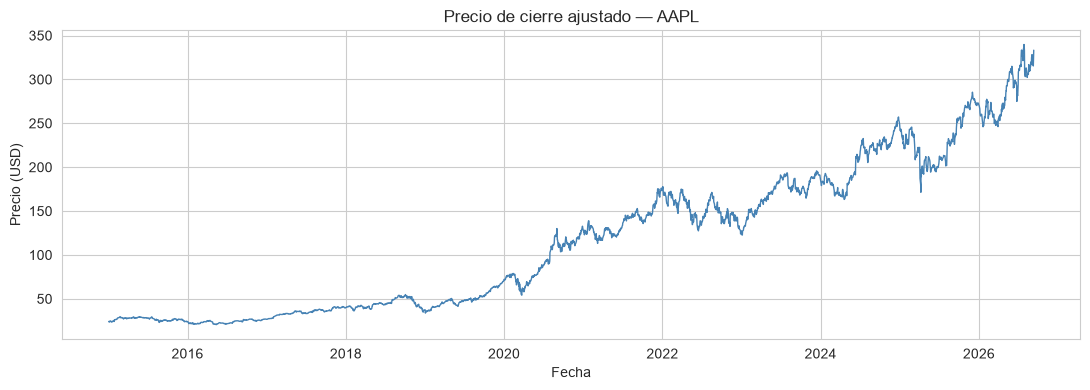

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(datos.index, datos["Close"], color="steelblue", linewidth=1)
ax.set_title(f"Precio de cierre ajustado — {TICKER}")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio (USD)")
plt.tight_layout()
plt.show()

## 3. Preprocesamiento

### 3.1 Frecuencia y valores faltantes

Forzamos una frecuencia de **días hábiles** (`"B"`) y rellenamos hacia adelante (`ffill`) los días sin negociación que puedan quedar como huecos: en ausencia de nueva información, el último precio conocido sigue siendo la mejor referencia disponible.

In [5]:
serie = datos["Close"].copy()
serie = serie.asfreq("B").ffill()

print(f"Observaciones tras ajustar la frecuencia: {len(serie)}")
print(f"Valores faltantes restantes: {serie.isna().sum()}")

Observaciones tras ajustar la frecuencia: 3051
Valores faltantes restantes: 0


### 3.2 División temporal en entrenamiento y prueba

A diferencia de un conjunto de datos tabular genérico, **no podemos mezclar ni barajar** las observaciones: usamos el tramo más antiguo para entrenar y el tramo más reciente para evaluar, replicando la situación real de un modelo que solo conoce el pasado.

In [6]:
FRACCION_TRAIN = 0.8
n_train = int(len(serie) * FRACCION_TRAIN)

serie_train = serie.iloc[:n_train]
serie_test = serie.iloc[n_train:]

print(f"Entrenamiento: {serie_train.index.min().date()} -> {serie_train.index.max().date()}  ({len(serie_train)} días)")
print(f"Prueba:        {serie_test.index.min().date()} -> {serie_test.index.max().date()}  ({len(serie_test)} días)")

Entrenamiento: 2015-01-02 -> 2024-05-09  (2440 días)
Prueba:        2024-05-10 -> 2026-09-11  (611 días)


### 3.3 Escalado

Las redes neuronales entrenan mejor (convergencia más rápida y estable) cuando las variables de entrada están en un rango acotado, por ejemplo `[0, 1]`. Usamos `MinMaxScaler` ajustándolo **únicamente con datos de entrenamiento**: si lo ajustáramos con toda la serie, el escalador "vería" el rango de precios del futuro (mínimos y máximos del conjunto de prueba) antes de tiempo — una forma sutil de fuga de información.

In [7]:
escalador = MinMaxScaler(feature_range=(0, 1))

serie_train_esc = escalador.fit_transform(serie_train.values.reshape(-1, 1)).flatten()
serie_test_esc = escalador.transform(serie_test.values.reshape(-1, 1)).flatten()

### 3.4 Ventanas deslizantes (*sliding windows*)

Para convertir la serie en un problema de aprendizaje supervisado, usamos los últimos `VENTANA` días como variables de entrada (`X`) para predecir el precio escalado del día siguiente (`y`): esto es exactamente la tarea *one-step-ahead*.

Para que la **primera** observación del conjunto de prueba tenga historia completa, anteponemos la cola del entrenamiento (son datos ya observados en el pasado, no información del futuro, así que no hay fuga).

In [8]:
VENTANA = 30  # días hábiles de historia usados para predecir el siguiente día

def crear_ventanas(serie_escalada, ventana):
    X, y = [], []
    for i in range(ventana, len(serie_escalada)):
        X.append(serie_escalada[i - ventana:i])
        y.append(serie_escalada[i])
    return np.array(X), np.array(y)

serie_test_con_historia = np.concatenate([serie_train_esc[-VENTANA:], serie_test_esc])

X_train, y_train = crear_ventanas(serie_train_esc, VENTANA)
X_test, y_test = crear_ventanas(serie_test_con_historia, VENTANA)

fechas_test = serie_test.index
assert len(fechas_test) == len(y_test)

print(f"X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

X_train: (2410, 30)   y_train: (2410,)
X_test:  (611, 30)   y_test:  (611,)


El MLP recibe cada ventana como un vector plano de tamaño `VENTANA`. La LSTM, en cambio, espera una secuencia con forma `(pasos_de_tiempo, características)`, así que añadimos una tercera dimensión.

In [9]:
X_train_lstm = X_train.reshape((X_train.shape[0], VENTANA, 1))
X_test_lstm = X_test.reshape((X_test.shape[0], VENTANA, 1))

print(f"X_train para LSTM: {X_train_lstm.shape}")
print(f"X_test para LSTM:  {X_test_lstm.shape}")

X_train para LSTM: (2410, 30, 1)
X_test para LSTM:  (611, 30, 1)


## 4. Modelo 1: Perceptrón Multicapa (MLP) sencillo

Arquitectura mínima: dos capas densas ocultas con activación `ReLU` y una capa de salida lineal (regresión, sin función de activación que acote el rango).

### 4.1 Fundamento teórico: ¿cómo funciona un MLP?

**La unidad básica: la neurona artificial.** Cada neurona recibe un vector de entradas $x_1, \dots, x_n$ (en nuestro caso, los precios escalados de la ventana), las combina mediante una **suma ponderada** más un sesgo, y pasa el resultado por una **función de activación** no lineal:

$$
z = \sum_{i=1}^{n} w_i x_i + b, \qquad a = \phi(z)
$$

Los pesos $w_i$ y el sesgo $b$ son los parámetros que la red *aprende* durante el entrenamiento; $\phi$ es fija (la elegimos nosotros al definir la arquitectura).

**¿Por qué hace falta una activación no lineal?** Si $\phi$ fuera la identidad, apilar varias capas densas seguiría siendo, en conjunto, una única transformación lineal de la entrada — sin importar cuántas capas agreguemos, el modelo no podría representar relaciones curvas o umbrales. La no linealidad es lo que le permite a una red de varias capas aproximar funciones arbitrariamente complejas (el resultado teórico detrás de esto se conoce como *teorema de aproximación universal*).

En nuestra arquitectura usamos `ReLU` (*Rectified Linear Unit*) en las capas ocultas:

$$
\phi_{\text{ReLU}}(z) = \max(0, z)
$$

Es la activación más usada en la práctica: es barata de calcular, y a diferencia de la sigmoide o la tangente hiperbólica, no "satura" para valores grandes de $z$ (su gradiente no se desvanece cuando la entrada es positiva), lo que hace más estable el entrenamiento de redes con varias capas.

**Arquitectura *feedforward*.** Un MLP organiza las neuronas en capas totalmente conectadas (*dense*): la salida de cada neurona de una capa alimenta a **todas** las neuronas de la siguiente. La información fluye en una sola dirección — de la entrada hacia la salida — sin ciclos y sin ningún mecanismo de memoria entre ejemplos. Esto tiene una consecuencia importante para nuestro problema: **el MLP no "sabe" que sus 30 entradas están ordenadas en el tiempo**; para la red son simplemente 30 números en un vector. Cualquier patrón temporal (tendencias, momentum) tiene que quedar codificado implícitamente en los pesos aprendidos, no en la arquitectura misma.

**¿Cómo aprende la red?** El ciclo de entrenamiento, en cada lote (*batch*) de ejemplos, es:

1. **Forward pass:** la ventana de entrada atraviesa las capas y produce una predicción $\hat y$.
2. **Cálculo de la pérdida:** se compara $\hat y$ con el valor real $y$ usando una función de pérdida — aquí, el error cuadrático medio (`mse`).
3. **Backpropagation:** usando la regla de la cadena, se calcula qué tanto contribuyó cada peso al error, capa por capa, de atrás hacia adelante.
4. **Actualización de pesos:** el optimizador (`adam`) ajusta cada peso en la dirección que reduce la pérdida, con un tamaño de paso adaptativo por parámetro.

Este ciclo se repite durante varias épocas hasta que la pérdida de validación deja de mejorar (de ahí el `EarlyStopping` que usamos más abajo).

| Capa | Tipo | Unidades | Activación | Rol |
|---|---|---|---|---|
| Entrada | — | 30 | — | Ventana de precios escalados |
| Oculta 1 | Densa | 64 | ReLU | Combina la ventana en patrones intermedios |
| Oculta 2 | Densa | 32 | ReLU | Refina esos patrones |
| Salida | Densa | 1 | Lineal | Precio escalado del día siguiente |

In [10]:
mlp = keras.Sequential([
    layers.Input(shape=(VENTANA,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="linear"),
], name="MLP_sencillo")

mlp.compile(optimizer="adam", loss="mse", metrics=["mae"])
mlp.summary()

Model: "MLP_sencillo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
parada_temprana_mlp = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=8, restore_best_weights=True
)

historia_mlp = mlp.fit(
    X_train, y_train,
    validation_split=0.1,   # Keras toma el ÚLTIMO 10% de los datos suministrados,
                             # respetando el orden temporal (no baraja antes de dividir)
    epochs=100,
    batch_size=32,
    callbacks=[parada_temprana_mlp],
    verbose=0,
)

print(f"Entrenamiento detenido en la época {len(historia_mlp.history['loss'])}")

Entrenamiento detenido en la época 46


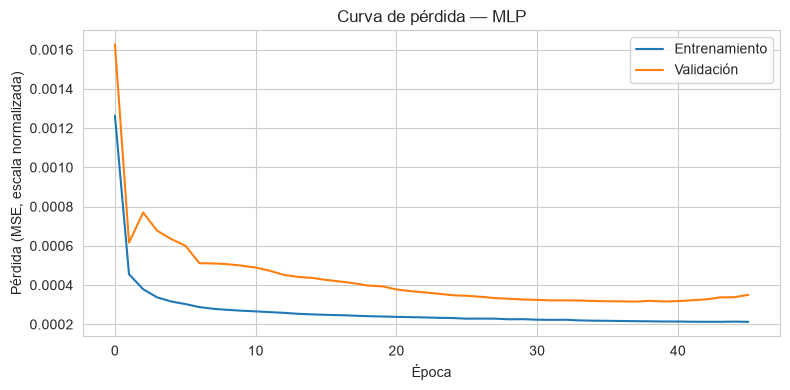

In [12]:
def graficar_curvas_perdida(historia, titulo):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(historia.history["loss"], label="Entrenamiento")
    ax.plot(historia.history["val_loss"], label="Validación")
    ax.set_title(titulo)
    ax.set_xlabel("Época")
    ax.set_ylabel("Pérdida (MSE, escala normalizada)")
    ax.legend()
    plt.tight_layout()
    plt.show()

graficar_curvas_perdida(historia_mlp, "Curva de pérdida — MLP")

## 5. Modelo 2: LSTM

Una LSTM procesa la ventana **paso a paso** (día por día) y mantiene un estado interno que actúa como memoria de corto y largo plazo, regulada por sus compuertas internas (*forget*, *input*, *output*). A diferencia del MLP, la red sabe en qué orden llegó cada observación.

### 5.1 Fundamento teórico: ¿cómo funciona una LSTM?

**Punto de partida: la RNN simple.** Una red recurrente (RNN) básica reutiliza los mismos pesos en cada paso de tiempo, combinando la entrada actual $x_t$ con el estado oculto del paso anterior $h_{t-1}$:

$$
h_t = \phi(W_x x_t + W_h h_{t-1} + b)
$$

Esto le da a la red una noción de secuencia — $h_t$ resume todo lo visto hasta el momento $t$. El problema aparece al entrenar: para calcular el gradiente en el paso 1 hay que retropropagar el error a través de los 30 pasos de la ventana, multiplicando repetidamente por los mismos pesos. Esos productos repetidos tienden a **desvanecerse** (o, con menos frecuencia, explotar), por lo que una RNN simple "olvida" rápidamente información de varios pasos atrás — justo el problema conocido como *vanishing gradient*.

**La solución de la LSTM: un estado de celda separado.** Una LSTM (*Long Short-Term Memory*) añade, junto al estado oculto $h_t$, un **estado de celda** $c_t$ que actúa como una cinta transportadora de memoria de largo plazo. La celda se actualiza mayormente con sumas y multiplicaciones elemento a elemento (no con multiplicaciones matriciales repetidas), lo que permite que la información viaje muchos pasos sin degradarse tan rápido.

Qué tanto se conserva, se agrega o se expone de esa memoria en cada paso lo deciden tres **compuertas** (*gates*), cada una una capa densa con activación sigmoide $\sigma$ (que produce valores entre 0 y 1, interpretables como "qué proporción dejar pasar"):

| Compuerta | Fórmula | Qué decide |
|---|---|---|
| Olvido (*forget*) | $f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$ | Qué parte de la memoria anterior $c_{t-1}$ se descarta |
| Entrada (*input*) | $i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$ | Qué parte de la información nueva se incorpora a la memoria |
| Salida (*output*) | $o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$ | Qué parte de la memoria se expone como salida en este paso |

Con esas tres compuertas, la actualización de la celda en cada paso de tiempo es:

$$
\tilde c_t = \tanh(W_c [h_{t-1}, x_t] + b_c) \qquad \text{(candidato de nueva información)}
$$

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde c_t \qquad \text{(memoria actualizada: lo que se conserva + lo nuevo)}
$$

$$
h_t = o_t \odot \tanh(c_t) \qquad \text{(estado oculto: lo que se expone en este paso)}
$$

donde $\odot$ denota multiplicación elemento a elemento.

**Intuición.** El estado de celda $c_t$ es la "memoria de largo plazo": la compuerta de olvido puede mantenerla casi intacta cuando conviene (evitando el desvanecimiento del gradiente), mientras que las compuertas de entrada y salida regulan qué información nueva entra y cuál se usa en cada instante. Es esta capacidad de *elegir qué recordar y qué olvidar* — en lugar de recalcular todo desde cero en cada paso como una RNN simple — lo que le da a la LSTM ventaja para capturar dependencias de más largo plazo.

**Cómo se usa aquí.** La capa `LSTM(50)` procesa los 30 días de la ventana uno por uno, actualizando $(h_t, c_t)$ en cada paso. Solo se conserva el estado oculto del **último** paso, $h_{30}$ — un vector de 50 números que resume toda la ventana — y ese vector alimenta la capa densa final que produce la predicción. A diferencia del MLP, aquí el orden de los 30 días sí es parte explícita de cómo se procesa la información.

In [13]:
lstm = keras.Sequential([
    layers.Input(shape=(VENTANA, 1)),
    layers.LSTM(50, activation="tanh"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="linear"),
], name="LSTM")

lstm.compile(optimizer="adam", loss="mse", metrics=["mae"])
lstm.summary()

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,065 (47.13 KB)

 Trainable params: 12,065 (47.13 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
parada_temprana_lstm = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=8, restore_best_weights=True
)

historia_lstm = lstm.fit(
    X_train_lstm, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[parada_temprana_lstm],
    verbose=0,
)

print(f"Entrenamiento detenido en la época {len(historia_lstm.history['loss'])}")

Entrenamiento detenido en la época 100


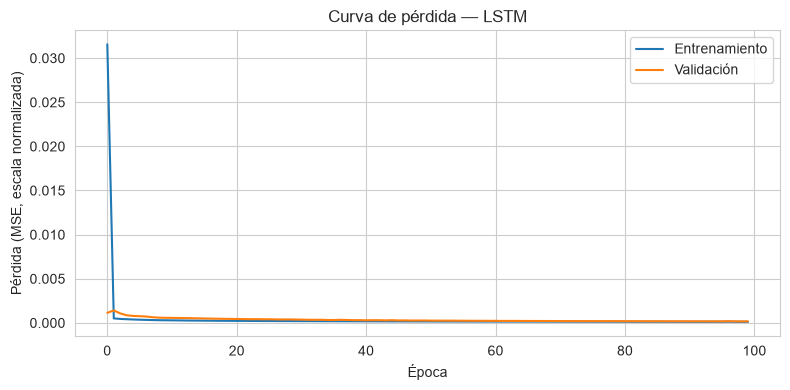

In [15]:
graficar_curvas_perdida(historia_lstm, "Curva de pérdida — LSTM")

## 6. Diagnóstico del desempeño

Evaluamos ambas redes en el conjunto de prueba y las comparamos contra una **línea base ingenua** (*naive / random walk*): predecir que el precio de mañana será igual al de hoy. En mercados razonablemente eficientes, superar esta línea base de forma consistente **no es trivial**, y es el primer criterio de sanidad para cualquier modelo de precios.

In [16]:
def invertir_escala(valores_escalados):
    return escalador.inverse_transform(np.asarray(valores_escalados).reshape(-1, 1)).flatten()

y_test_real = invertir_escala(y_test)

pred_mlp = invertir_escala(mlp.predict(X_test, verbose=0).flatten())
pred_lstm = invertir_escala(lstm.predict(X_test_lstm, verbose=0).flatten())

# Línea base ingenua: el último valor de cada ventana ("hoy") como predicción de "mañana"
pred_naive = invertir_escala(X_test[:, -1])

In [17]:
def calcular_metricas(y_real, y_pred, nombre):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
    r2 = r2_score(y_real, y_pred)
    return {"Modelo": nombre, "RMSE": rmse, "MAE": mae, "MAPE (%)": mape, "R²": r2}

metricas = pd.DataFrame([
    calcular_metricas(y_test_real, pred_naive, "Ingenuo (random walk)"),
    calcular_metricas(y_test_real, pred_mlp, "MLP"),
    calcular_metricas(y_test_real, pred_lstm, "LSTM"),
]).set_index("Modelo")

metricas.round(4)

,RMSE,MAE,MAPE (%),R²
Modelo,,,,
Ingenuo (random walk),4.1457,2.7835,1.1500,0.9870
MLP,5.5280,4.0384,1.6772,0.9768
LSTM,5.0782,3.6627,1.4552,0.9804


In [18]:
mejor_red = metricas.drop(index="Ingenuo (random walk)")["RMSE"].idxmin()
supera_ingenuo = metricas.loc[mejor_red, "RMSE"] < metricas.loc["Ingenuo (random walk)", "RMSE"]

print(f"Red neuronal con menor RMSE: {mejor_red}")
print(f"¿Supera a la línea base ingenua en RMSE? {'Sí' if supera_ingenuo else 'No'}")

Red neuronal con menor RMSE: LSTM
¿Supera a la línea base ingenua en RMSE? No


### 6.1 Predicho vs. real

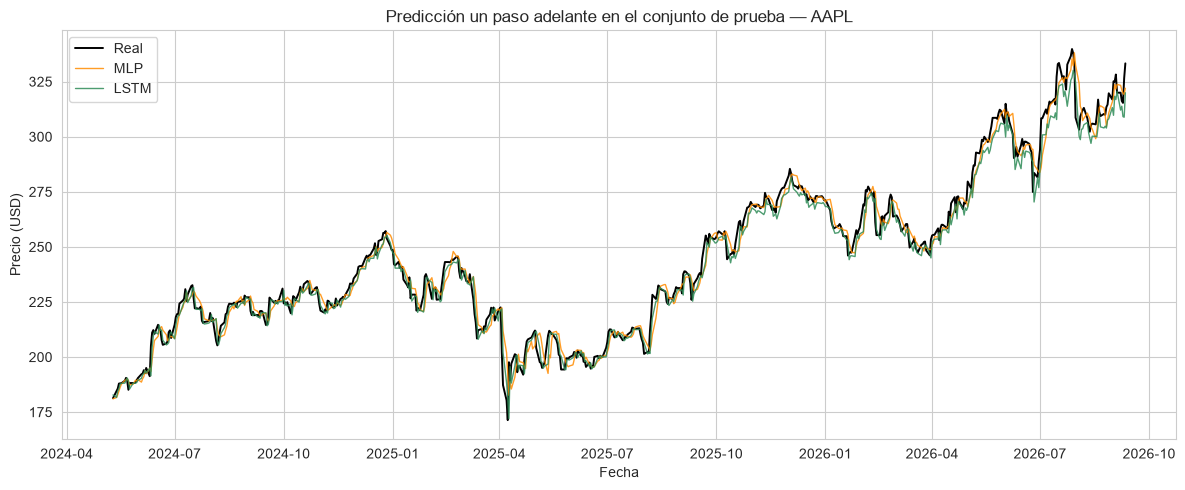

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(fechas_test, y_test_real, label="Real", color="black", linewidth=1.4)
ax.plot(fechas_test, pred_mlp, label="MLP", color="darkorange", linewidth=1, alpha=0.85)
ax.plot(fechas_test, pred_lstm, label="LSTM", color="seagreen", linewidth=1, alpha=0.85)
ax.set_title(f"Predicción un paso adelante en el conjunto de prueba — {TICKER}")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio (USD)")
ax.legend()
plt.tight_layout()
plt.show()

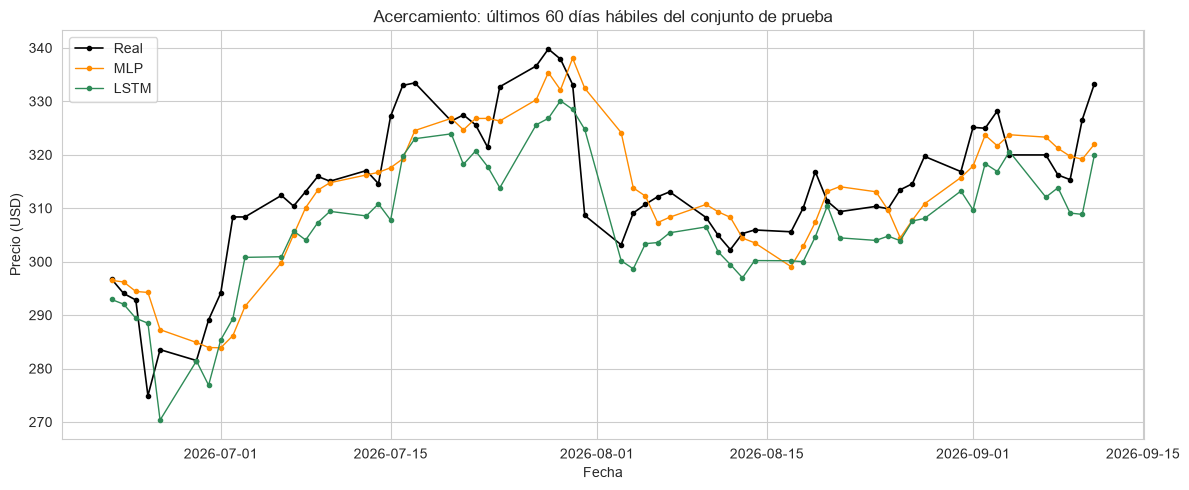

In [20]:
# Acercamiento a los últimos 60 días de prueba: en la vista completa las tres
# series tienden a superponerse porque el precio de un día a otro cambia poco
ULTIMOS_DIAS = 60

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(fechas_test[-ULTIMOS_DIAS:], y_test_real[-ULTIMOS_DIAS:], label="Real", color="black", marker="o", markersize=3, linewidth=1.2)
ax.plot(fechas_test[-ULTIMOS_DIAS:], pred_mlp[-ULTIMOS_DIAS:], label="MLP", color="darkorange", marker="o", markersize=3, linewidth=1)
ax.plot(fechas_test[-ULTIMOS_DIAS:], pred_lstm[-ULTIMOS_DIAS:], label="LSTM", color="seagreen", marker="o", markersize=3, linewidth=1)
ax.set_title(f"Acercamiento: últimos {ULTIMOS_DIAS} días hábiles del conjunto de prueba")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio (USD)")
ax.legend()
plt.tight_layout()
plt.show()

### 6.2 Análisis de residuales

Un buen modelo debería dejar residuales sin patrones evidentes: centrados en cero y sin tendencias sistemáticas en el tiempo.

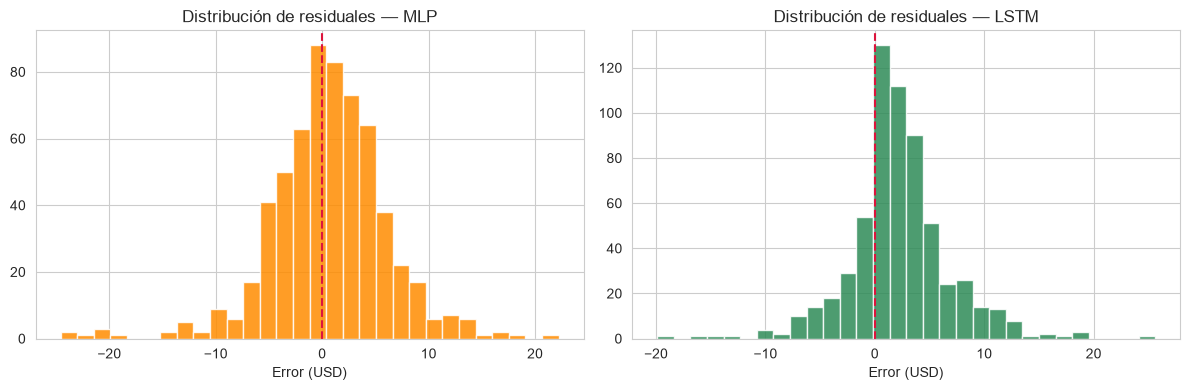

In [21]:
residuales_mlp = y_test_real - pred_mlp
residuales_lstm = y_test_real - pred_lstm

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, residuales, nombre, color in zip(
    axes, [residuales_mlp, residuales_lstm], ["MLP", "LSTM"], ["darkorange", "seagreen"]
):
    ax.hist(residuales, bins=30, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(0, color="crimson", linestyle="--")
    ax.set_title(f"Distribución de residuales — {nombre}")
    ax.set_xlabel("Error (USD)")
plt.tight_layout()
plt.show()

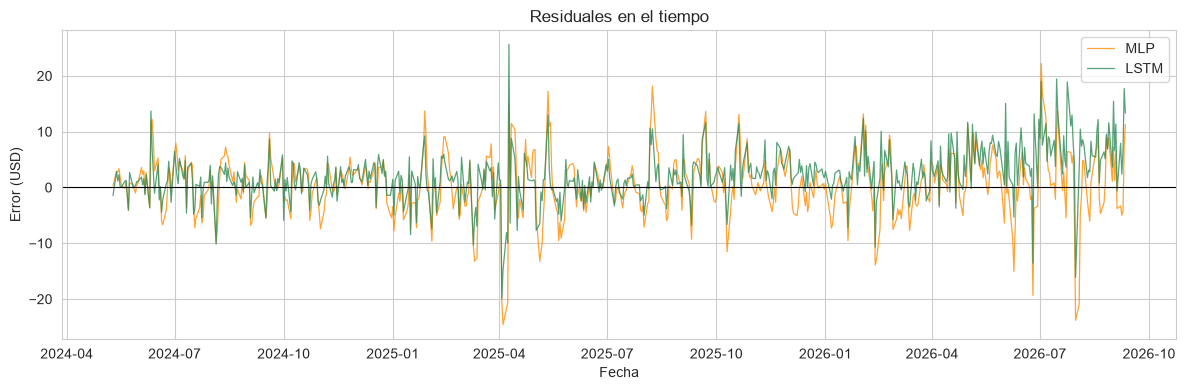

In [22]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(fechas_test, residuales_mlp, label="MLP", color="darkorange", alpha=0.8, linewidth=0.9)
ax.plot(fechas_test, residuales_lstm, label="LSTM", color="seagreen", alpha=0.8, linewidth=0.9)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Residuales en el tiempo")
ax.set_xlabel("Fecha")
ax.set_ylabel("Error (USD)")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Predicción *one-step-ahead* fuera de muestra

Usamos los últimos `VENTANA` días **realmente observados** (incluyendo el dato más reciente descargado) para proyectar el precio del siguiente día hábil, algo que todavía no ha ocurrido.

In [23]:
ultima_ventana_real = serie.values[-VENTANA:]
ultima_ventana_esc = escalador.transform(ultima_ventana_real.reshape(-1, 1)).flatten()

entrada_mlp = ultima_ventana_esc.reshape(1, VENTANA)
entrada_lstm = ultima_ventana_esc.reshape(1, VENTANA, 1)

pred_manana_mlp = invertir_escala(mlp.predict(entrada_mlp, verbose=0).flatten())[0]
pred_manana_lstm = invertir_escala(lstm.predict(entrada_lstm, verbose=0).flatten())[0]

ultimo_precio = serie.values[-1]
ultima_fecha = serie.index[-1]
pred_manana_naive = ultimo_precio

resumen_prediccion = pd.DataFrame({
    "Modelo": ["Ingenuo (random walk)", "MLP", "LSTM"],
    "Predicción próximo día hábil (USD)": [pred_manana_naive, pred_manana_mlp, pred_manana_lstm],
})
resumen_prediccion["Variación vs. último cierre"] = (
    (resumen_prediccion["Predicción próximo día hábil (USD)"] / ultimo_precio - 1) * 100
).map(lambda x: f"{x:+.3f}%")

print(f"Último cierre disponible: {ultimo_precio:.2f} USD ({ultima_fecha.date()})")
resumen_prediccion

Último cierre disponible: 333.27 USD (2026-09-11)


,Modelo,Predicción próximo día hábil (USD),Variación vs. último cierre
0,Ingenuo (random walk),333.269989,+0.000%
1,MLP,326.956085,-1.895%
2,LSTM,323.934753,-2.801%


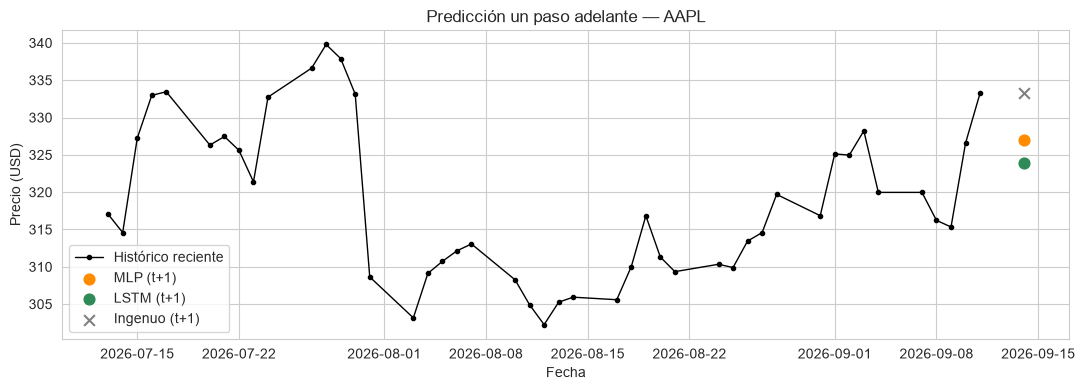

In [24]:
DIAS_A_MOSTRAR = 45
siguiente_fecha = serie.index[-1] + pd.tseries.offsets.BDay(1)

fig, ax = plt.subplots(figsize=(11, 4))
tramo = serie.iloc[-DIAS_A_MOSTRAR:]
ax.plot(tramo.index, tramo.values, color="black", marker="o", markersize=3, linewidth=1, label="Histórico reciente")

ax.scatter([siguiente_fecha], [pred_manana_mlp], color="darkorange", zorder=5, s=60, label="MLP (t+1)")
ax.scatter([siguiente_fecha], [pred_manana_lstm], color="seagreen", zorder=5, s=60, label="LSTM (t+1)")
ax.scatter([siguiente_fecha], [pred_manana_naive], color="gray", zorder=5, s=60, marker="x", label="Ingenuo (t+1)")

ax.set_title(f"Predicción un paso adelante — {TICKER}")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio (USD)")
ax.legend()
plt.tight_layout()
plt.show()

> **Advertencia:** la predicción anterior corresponde a un único día y a un único activo, con modelos entrenados sin búsqueda exhaustiva de hiperparámetros. No debe usarse como base para decisiones de inversión reales.

## 8. Conclusiones y limitaciones

- **El punto de referencia importa:** en precios financieros, el modelo ingenuo (*random walk*) es un competidor sorprendentemente fuerte. Superarlo de forma consistente en RMSE/MAE, y no solo en una corrida particular, es evidencia relevante sobre si la red está aprendiendo señal real o simplemente replicando el último precio observado.
- **MLP vs. LSTM:** la LSTM incorpora una noción explícita de orden temporal a través de su estado recurrente; el MLP no. Compara las métricas de la sección 6 y las curvas de pérdida: ¿la arquitectura recurrente se traduce en una mejora práctica en este activo y horizonte, o el costo adicional de complejidad no se justifica?
- **Un solo split no es suficiente:** aquí usamos una única partición entrenamiento/prueba por simplicidad didáctica. En un proyecto real conviene usar *walk-forward validation* (reentrenar y evaluar en ventanas sucesivas) para tener una estimación más robusta del desempeño esperado.
- **Variables exógenas:** este cuaderno usa únicamente el precio pasado del propio activo. Variables macro, indicadores técnicos u otros activos correlacionados podrían aportar información adicional.
- **Próximos pasos sugeridos:** GRU y arquitecturas basadas en atención (*Transformers* para series de tiempo), *ensembles* de modelos, y validación con métricas orientadas a decisión (por ejemplo, acierto direccional) en lugar de solo error de magnitud.